# Predicting Insurance Claim Amounts

## Problem Statement

The goal of this project is to predict medical insurance claim charges based on personal information such as age, BMI, smoking status, gender, and region using Linear Regression.

This project also analyzes how BMI, age, and smoking habits affect insurance charges.


In [4]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [5]:
# Load dataset

df = pd.read_csv("../data/insurance.csv")

# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# Dataset shape

print("Dataset Shape:")
print(df.shape)

# Dataset columns
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.00000

## Dataset Understanding

The dataset contains personal information such as age, BMI, gender, smoking status, number of children, and region.

Target Variable:

- charges

Independent Variables:

- age
- sex
- bmi
- children
- smoker
- region


In [7]:
# Check missing values

print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [9]:
# Remove duplicates

df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [10]:
# Convert categorical columns to numerical

df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


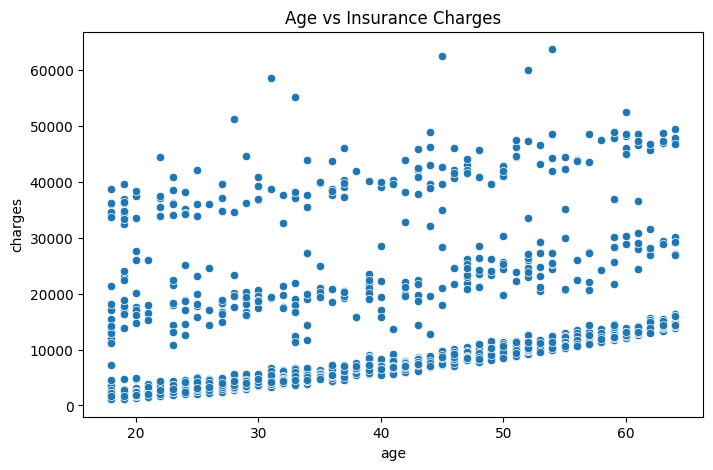

In [11]:
# Age vs Charges

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='charges',
    data=df
)

plt.title("Age vs Insurance Charges")
plt.show()

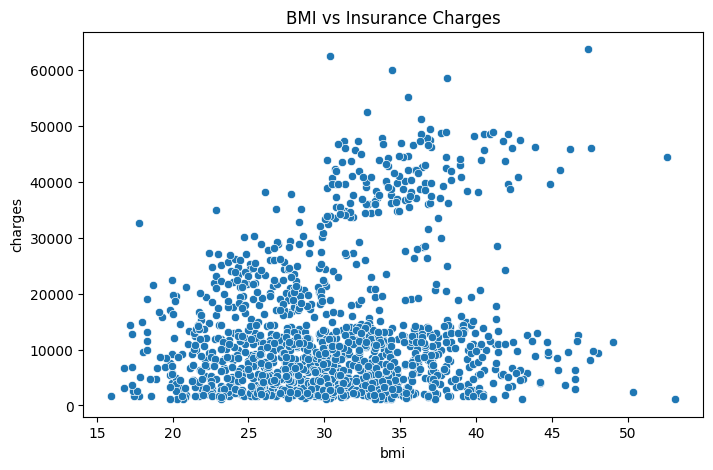

In [12]:
# BMI vs Charges

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='bmi',
    y='charges',
    data=df
)

plt.title("BMI vs Insurance Charges")
plt.show()

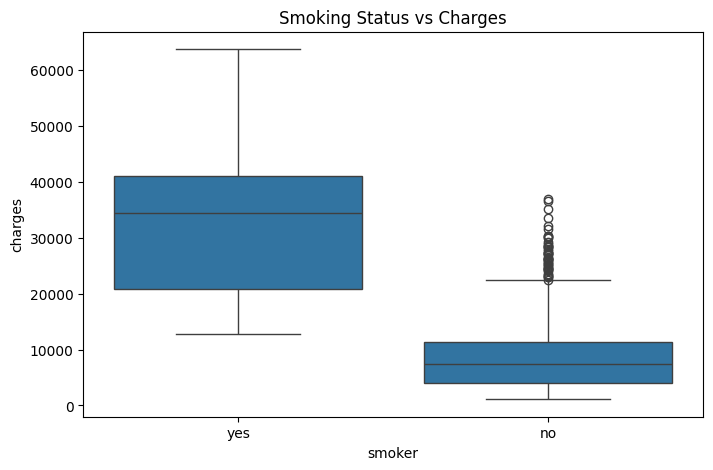

In [13]:
# Smoking Status vs Charges

plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoker',
    y='charges',
    data=df
)

plt.title("Smoking Status vs Charges")
plt.show()

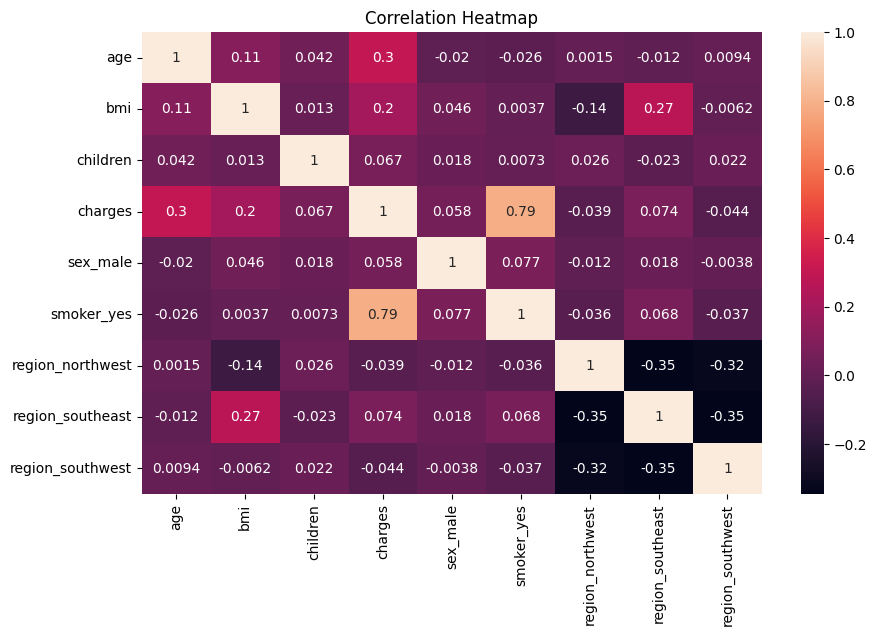

In [14]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    df_encoded.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Features and Target Variable

X = df_encoded.drop('charges', axis=1)

y = df_encoded['charges']

In [16]:
# Split training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1069, 8)
(268, 8)


In [17]:
# Train model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [18]:
# Predictions

y_pred = model.predict(X_test)

print(y_pred[:10])

[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706 13149.72235307 30446.76067941  1453.28881259
 10633.01840233 11318.94379361]


In [19]:
# Mean Absolute Error

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 4177.045561036319


In [20]:
# Root Mean Squared Error

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", rmse)

RMSE: 5956.342894363588


# Conclusion

The Linear Regression model successfully predicted insurance charges.

Key Findings:

- Smoking status strongly impacts insurance charges.
- BMI affects insurance cost.
- Insurance charges increase with age.

Model performance was evaluated using:

- MAE
- RMSE
